# Random Forest

Using the Random Forest algorithm, a higher level of accuracy and score is achieved, <br>
in addition to reducing the likelihood of overfitting due to artificial injection caused by SMOTE

## Importing libraries

In [1]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [2]:
# Open the csv file
Balanced_CCDF = pd.read_parquet('../../data/processed/Balanced_creditcard.parquet')

In [3]:
# Creating a separation between features and target
x = Balanced_CCDF.drop('Class', axis = 1)
y = Balanced_CCDF['Class']

## Model Training

In [4]:
# Selecting the percentage of rows that are going to be used as training 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [5]:
# Training the model to predict the chances of fraud
model = RandomForestClassifier()

model = model.fit(x_train, y_train)
y_predict = model.predict(x_test)

## Evaluate Model

In [6]:
# _val = _test
print('Classification Metrics: \n', classification_report(y_test, y_predict))

Classification Metrics: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     84880
           1       1.00      1.00      1.00     85072

    accuracy                           1.00    169952
   macro avg       1.00      1.00      1.00    169952
weighted avg       1.00      1.00      1.00    169952



<Axes: >

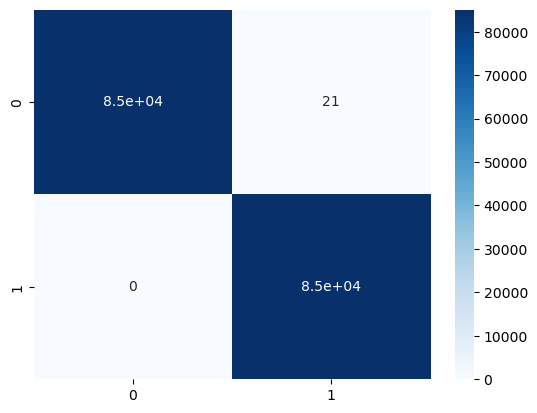

In [7]:
sns.heatmap(confusion_matrix(y_test, y_predict), annot = True, cmap =  'Blues')